In [51]:
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

def dN_dzdm(z, m, lf, Kcorr=None, area_deg2=1.0):
    """
    Compute dN / dz / dm for QSOs from a luminosity function.

    Parameters
    ----------
    z : float or array
        Redshift.

    m : float or array
        Apparent magnitude.

    lf : function
        QSO luminosity function lf(M, z), returning
        dn / (dV dM) in Mpc^-3 mag^-1.

    Kcorr : function, optional
        K-correction K(z). If None, K(z)=0.

    area_deg2 : float
        Survey area in square degrees.

    Returns
    -------
    dN_dzdm : float or array
        Number of QSOs per unit redshift per unit magnitude
        in the specified survey area.
    """

    z = np.asarray(z)
    m = np.asarray(m)

    # Distance modulus
    DL = cosmo.luminosity_distance(z).to(u.pc).value
    DM = 5.0 * np.log10(DL / 10.0)

    # K-correction
    K = 0.0 if Kcorr is None else Kcorr(z)

    # Apparent magnitude -> absolute magnitude
    M = m - DM - K

    # Luminosity function
    Phi = lf(M, z)

    # Comoving volume element [Mpc^3 sr^-1 dz^-1]
    dV_dz_dOmega = cosmo.differential_comoving_volume(z).to(
        u.Mpc**3 / u.sr
    ).value

    # Survey area: deg^2 -> steradians
    area_sr = area_deg2 * (np.pi / 180.0)**2

    # dN / dz / dm
    return area_sr * dV_dz_dOmega * Phi
    
def qso_lf(M, z):
    log_phi_star = -6.0
    M_star = -25.0
    alpha = -1.5
    beta = -3.5

    phi_star = 10**log_phi_star

    return phi_star / (
        10**(0.4 * (alpha + 1) * (M - M_star))
        +
        10**(0.4 * (beta + 1) * (M - M_star))
    )
from scipy.integrate import simpson

def n_of_z(z_arr, m_max, lf, Kcorr=None, m_min=-30.0, n_mgrid=201):
    """
    Surface density of QSOs per unit redshift, per deg^2,
    for objects brighter than m_max:

        n(z; m<m_max) = ∫_{m_min}^{m_max} dN/dz/dm  dm   [deg^-2]

    Parameters
    ----------
    z_arr : float or array
        Redshift(s) at which to evaluate n(z).
    m_max : float
        Faint magnitude limit of the survey.
    m_min : float
        Bright magnitude cutoff for the integral (should be bright
        enough that the LF contributes ~0 there).
    n_mgrid : int
        Number of magnitude grid points for the integration.
    """
    z_arr = np.atleast_1d(z_arr).astype(float)
    m_arr = np.linspace(m_min, m_max, n_mgrid)

    # broadcast to (nz, nm)
    Zg, Mg = np.meshgrid(z_arr, m_arr, indexing='ij')
    dNdzdm = dN_dzdm(Zg, Mg, lf, Kcorr=Kcorr, area_deg2=1.0)

    # integrate over magnitude at each z
    n_z = simpson(dNdzdm, x=m_arr, axis=1)
    return n_z  # shape (nz,), units: deg^-2 per unit z

Surface density N(m<23) = 932.24 deg^-2


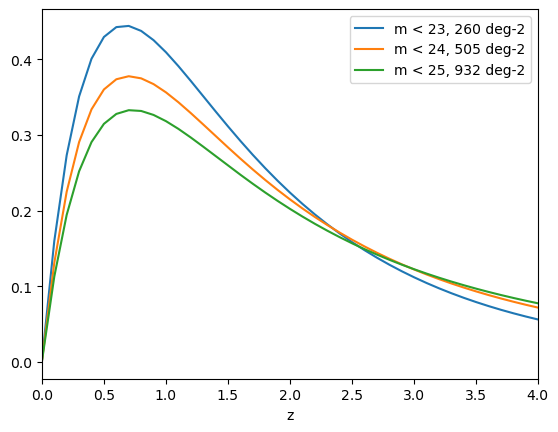

In [52]:
z_arr = np.linspace(0.0001, 100.0, 1000)
for m_max in [23, 24, 25]:
    n_z = n_of_z(z_arr, m_max=m_max, lf=qso_lf)   # deg^-2 per dz
    N_total = simpson(n_z, x=z_arr)   # deg^-2
    plt.plot(z_arr, n_z/np.trapz(n_z,z_arr), label = f'm < {m_max}, {N_total:.0f} deg-2')
plt.legend()
plt.xlabel('z')
plt.xlim(0, 4)
print(f"Surface density N(m<23) = {N_total:.2f} deg^-2")